# UFO Sightings (1949–2014): EDA + Cleaning + Probability + ML (mini-project)

## 0) Цель и вопросы
Датасет: ~80k наблюдений НЛО (1949–2014): город/штат/страна, координаты, форма, длительность, дата/время, комментарии.
Цели:
1) Какие формы встречаются чаще всего?
2) С 2000 года: как менялась динамика ежегодных наблюдений?
3) США: какие штаты лидируют по количеству наблюдений и почему так может быть?
4) Очистка данных: распределение длительности (гистограмма) + инсайты из комментариев.
5) Расширения: сезонность/суточность, проверки гипотез, базовые ML-модели (классификация/регрессия), NLP.

## 1) Загрузка и первичный осмотр
- Размер, типы, пропуски
- Дубликаты
- Диапазоны lat/lon
- Быстрая оценка «сырости» полей duration/shape/comments

## 2) Очистка и feature engineering (ключевые поля)
- datetime -> pandas datetime + year/month/dow/hour
- date posted -> pandas datetime + lag_days = posted - sighting
- shape -> normalize (lower/strip), rare -> "other"
- duration (seconds) -> numeric extraction + фильтр/каппинг выбросов + log1p(duration)
- city/state/country -> нормализация текста (lower/strip), явные пустые -> NaN
- latitude/longitude -> фильтр валидности (lat [-90,90], lon [-180,180])

## 3) Анализ по задачам
### 3.1 Топ форм НЛО
- Bar chart топ-N + доли

### 3.2 Динамика наблюдений с 2000 года
- Count per year (line)
- Комментарий о смещениях (интернет, сайты репортинга, культурные эффекты)

### 3.3 США: топ штатов
- Bar chart топ-15
- Нормировка на население (опционально, если найдём данные)
- Гипотезы о причинах (репортинг ≠ реальное явление)

### 3.4 Длительность
- Гистограмма log1p(duration_seconds)
- Boxplot/violin по топ-формам (log scale)
- Выбросы: топ самых длинных кейсов + их комментарии

### 3.5 Комментарии (NLP-lite)
- Длина текста (символы/слова)
- Частотные слова/биграммы
- Простые теги по ключевым словам (triangle/disk/light/military/silent/fast...)

## 4) 10 расширений (вероятность + ML + визуализация)
- Heatmap hour×month, chi-square тест равномерности
- Пуассон/негативный биномиальный счёт наблюдений
- Детектор аномалий/всплесков по времени
- Задержка публикации: распределение lag_days
- Гео-плотность (hexbin/KDE) по США
- Shape vs duration: Kruskal–Wallis
- Topic modeling (TF-IDF + NMF/LDA) на comments
- Классификация shape (top-K) по метаданным
- Регрессия log_duration
- Кластеризация наблюдений (KMeans/GMM/HDBSCAN) + проекции PCA/UMAP

## 5) Итоги и ограничения
- 8–12 выводов
- Какие смещения/ошибки есть в данных
- Что можно улучшить следующей итерацией


In [5]:
# === Imports ===
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# (опционально) удобные настройки вывода
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Read file ===
# Положи файл рядом с ноутбуком:
# - если это CSV: ufo_sightings_scrubbed.csv
# - если без расширения: укажи точное имя файла

path = "ufo_sightings_scrubbed.csv"  # <- при необходимости поменяй

df = pd.read_csv(path)
# подчистим имена колонок от пробелов/невидимых символов
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace("\ufeff", "", regex=False)  # BOM на всякий
)

# на всякий случай: приведём к нижнему регистру
df.columns = df.columns.str.lower()

print("shape:", df.shape)
display(df.head(5))
df.info()


shape: (80332, 11)


C:\Users\Shaim\AppData\Local\Temp\ipykernel_24396\1423630198.py:19: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80332 non-null  object 
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80332 non-null  object 
 10  longitude             80332 non-null  float64
dtypes: float64(1), object(10)
memory usage: 6.7+ MB


In [6]:
df.columns.tolist()

['datetime',
 'city',
 'state',
 'country',
 'shape',
 'duration (seconds)',
 'duration (hours/min)',
 'comments',
 'date posted',
 'latitude',
 'longitude']

## 2) Cleaning + Feature Engineering
Сделаем:
- datetime → dt + year/month/dow/hour
- date posted → posted_dt + lag_days
- country/state/city/shape → нормализация текста
- duration (seconds) → число + фильтр/каппинг + log1p
- latitude/longitude → проверка валидности
- comments → html-unescape + длины текста/слов


In [7]:
import re, html
import numpy as np
import pandas as pd

def normalize_str(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.strip()
         .str.lower()
         .replace({"": pd.NA, "nan": pd.NA})
    )

def choose_best_datetime_parse(s: pd.Series, sample_n=5000):
    s2 = s.dropna().astype(str)
    if len(s2) == 0:
        return dict(dayfirst=False, score=0)

    sample = s2.sample(min(sample_n, len(s2)), random_state=42)

    p1 = pd.to_datetime(sample, errors="coerce", dayfirst=False, infer_datetime_format=True)
    p2 = pd.to_datetime(sample, errors="coerce", dayfirst=True,  infer_datetime_format=True)

    score1 = p1.notna().mean()
    score2 = p2.notna().mean()
    best = dict(dayfirst=bool(score2 > score1), score=float(max(score1, score2)))
    return best

def parse_duration_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    # вытаскиваем первое число (целое/дробное)
    m = re.search(r"(\d+(\.\d+)?)", s.replace(",", "."))
    return float(m.group(1)) if m else np.nan

def clean_comment(x):
    if pd.isna(x):
        return pd.NA
    # html entities типа &#44; &amp;
    t = html.unescape(str(x))
    # уберём лишние пробелы
    t = re.sub(r"\s+", " ", t).strip()
    return t

# === preserve raw ===
df_raw = df.copy()

# === normalize columns (optional) ===
# оставим оригинальные имена, но сделаем удобные алиасы
colmap = {
    "duration (seconds)": "duration_seconds",
    "duration (hours/min)": "duration_hm",
    "date posted": "date_posted",
}
df = df.rename(columns=colmap)

# === normalize text cols ===
for c in ["city", "state", "country", "shape"]:
    if c in df.columns:
        df[c] = normalize_str(df[c])

# === datetime parsing (auto choose dayfirst) ===
dt_choice = choose_best_datetime_parse(df["datetime"])
print("datetime parse choice:", dt_choice)
df["dt"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=dt_choice["dayfirst"])

posted_choice = choose_best_datetime_parse(df["date_posted"])
print("date_posted parse choice:", posted_choice)
df["posted_dt"] = pd.to_datetime(df["date_posted"], errors="coerce", dayfirst=posted_choice["dayfirst"])

# features
df["year"] = df["dt"].dt.year
df["month"] = df["dt"].dt.month
df["dow"] = df["dt"].dt.dayofweek  # 0=Mon
df["hour"] = df["dt"].dt.hour

df["lag_days"] = (df["posted_dt"] - df["dt"]).dt.total_seconds() / 86400.0

# === duration seconds ===
df["duration_seconds"] = df["duration_seconds"].apply(parse_duration_seconds)
df.loc[df["duration_seconds"] <= 0, "duration_seconds"] = np.nan
df["log_duration"] = np.log1p(df["duration_seconds"])

# каппинг хвоста (чтобы графики были читабельны)
cap = df["duration_seconds"].quantile(0.99)
df["duration_seconds_cap"] = df["duration_seconds"].clip(upper=cap)
df["log_duration_cap"] = np.log1p(df["duration_seconds_cap"])
print("duration 99% cap:", cap)

# === lat/lon sanity ===
df["latitude"]  = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

valid_geo = df["latitude"].between(-90, 90) & df["longitude"].between(-180, 180)
df.loc[~valid_geo, ["latitude", "longitude"]] = np.nan

# === comments cleanup + simple text features ===
df["comments_clean"] = df["comments"].apply(clean_comment)
df["comment_chars"] = df["comments_clean"].astype("string").str.len()
df["comment_words"] = df["comments_clean"].astype("string").str.split().str.len()

df.head(3)


C:\Users\Shaim\AppData\Local\Temp\ipykernel_24396\2893711104.py:20: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  p1 = pd.to_datetime(sample, errors="coerce", dayfirst=False, infer_datetime_format=True)
C:\Users\Shaim\AppData\Local\Temp\ipykernel_24396\2893711104.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  p2 = pd.to_datetime(sample, errors="coerce", dayfirst=True,  infer_datetime_format=True)
C:\Users\Shaim\AppData\Local\Temp\ipykernel_24396\2893711104.py:21: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified.

datetime parse choice: {'dayfirst': False, 'score': 1.0}
date_posted parse choice: {'dayfirst': False, 'score': 1.0}
duration 99% cap: 14400.0


,datetime,city,state,country,shape,duration_seconds,duration_hm,comments,date_posted,latitude,longitude,dt,posted_dt,year,month,dow,hour,lag_days,log_duration,duration_seconds_cap,log_duration_cap,comments_clean,comment_chars,comment_words
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,2004-04-27,29.883056,-97.941111,1949-10-10 20:30:00,2004-04-27,1949,10,0,20,19922.145833,7.901377,2700.0,7.901377,This event took place in early fall around 194...,135,24
1,1949-10-10 21:00:00,lackland afb,tx,<NA>,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.384210,-98.581082,1949-10-10 21:00:00,2005-12-16,1949,10,0,21,20520.125000,8.881975,7200.0,8.881975,"1949 Lackland AFB, TX. Lights racing across th...",87,17
2,1955-10-10 17:00:00,chester (uk/england),<NA>,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.200000,-2.916667,1955-10-10 17:00:00,2008-01-21,1955,10,0,17,19095.291667,3.044522,20.0,3.044522,"Green/Orange circular disc over Chester, England",48,6


## 2.1 Быстрый Quality Report


In [8]:
def quality_report(df):
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().mean().round(4),
        "n_unique": df.nunique(dropna=True),
    }).sort_values("missing", ascending=False)
    return rep

qr = quality_report(df)
display(qr.head(20))

print("Rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Parsed dt non-null:", df["dt"].notna().mean().round(4))
print("Parsed posted_dt non-null:", df["posted_dt"].notna().mean().round(4))


,dtype,missing,n_unique
country,string,0.1204,5
state,string,0.0722,67
shape,string,0.0241,29
comment_words,object,0.0002,35
comment_chars,Int64,0.0002,134
comments_clean,object,0.0002,79994
comments,object,0.0002,79997
month,int32,0.0000,12
log_duration_cap,float64,0.0000,470
duration_seconds_cap,float64,0.0000,470


Rows: 80332
Duplicate rows: 0
Parsed dt non-null: 1.0
Parsed posted_dt non-null: 1.0


## 3.1 Какие формы НЛО встречаются чаще всего


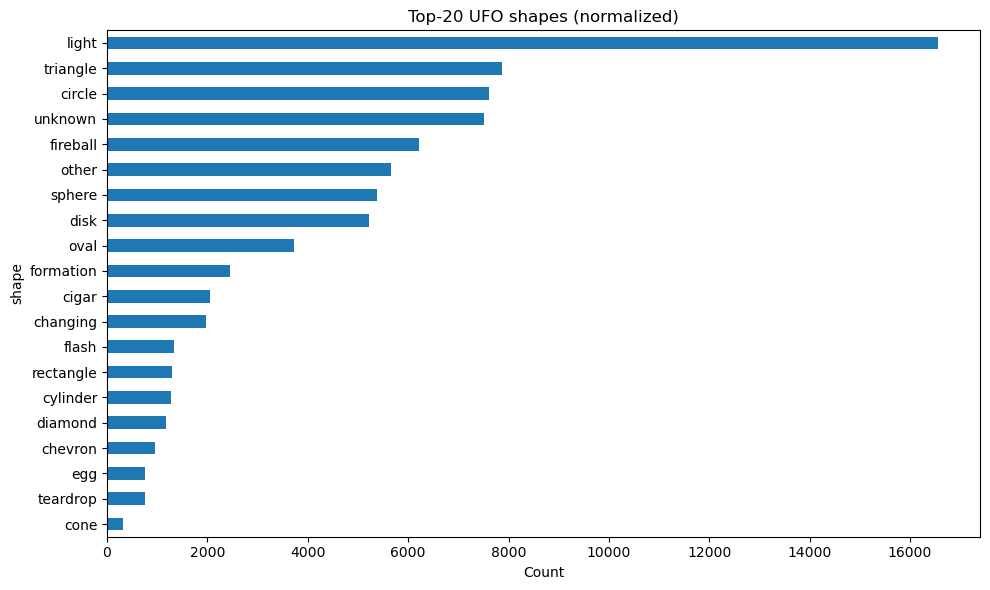

,count
shape,
light,16565
triangle,7865
circle,7608
unknown,7516
fireball,6208
other,5649
sphere,5387
disk,5213
oval,3733


In [9]:
import matplotlib.pyplot as plt

shape_counts = (
    df["shape"]
    .fillna("unknown")
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,6))
shape_counts.sort_values().plot(kind="barh")
plt.title("Top-20 UFO shapes (normalized)")
plt.xlabel("Count")
plt.ylabel("shape")
plt.tight_layout()
plt.show()

display(shape_counts.to_frame("count"))


## 3.2 С 2000 года: динамика ежегодного числа наблюдений


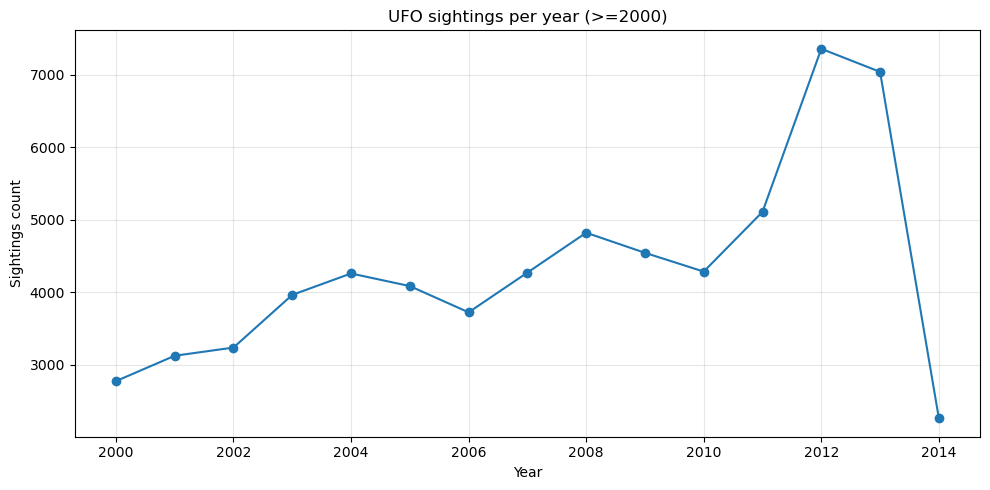

,count
year,
2000,2772
2001,3122
2002,3235
2003,3962
2004,4257
2005,4083
2006,3721
2007,4269
2008,4819


In [10]:
df_2000 = df[df["year"] >= 2000].copy()

yearly = df_2000.groupby("year").size()

plt.figure(figsize=(10,5))
yearly.plot(kind="line", marker="o")
plt.title("UFO sightings per year (>=2000)")
plt.xlabel("Year")
plt.ylabel("Sightings count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(yearly.to_frame("count").tail(15))


## 3.3 США: в каких штатах больше всего наблюдений
(Важно: это “где чаще сообщают”, а не обязательно “где чаще реально происходит”.)


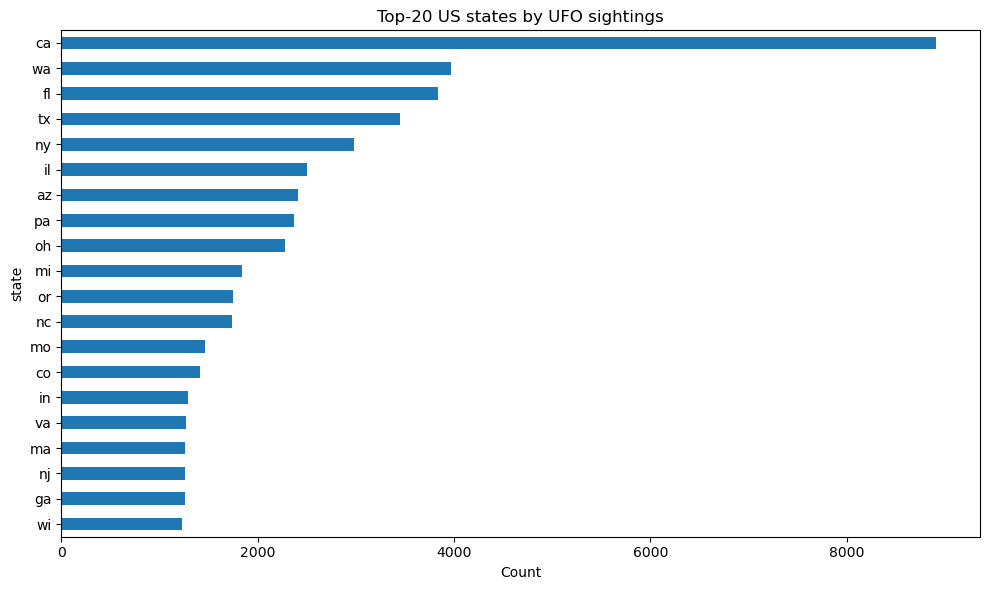

,count
state,
ca,8912
wa,3966
fl,3835
tx,3447
ny,2980
il,2499
az,2414
pa,2366
oh,2275


In [11]:
df_us = df[df["country"] == "us"].copy()
state_counts = (
    df_us["state"]
    .dropna()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,6))
state_counts.sort_values().plot(kind="barh")
plt.title("Top-20 US states by UFO sightings")
plt.xlabel("Count")
plt.ylabel("state")
plt.tight_layout()
plt.show()

display(state_counts.to_frame("count"))


## 3.4 Длительность наблюдений: распределение (после очистки)


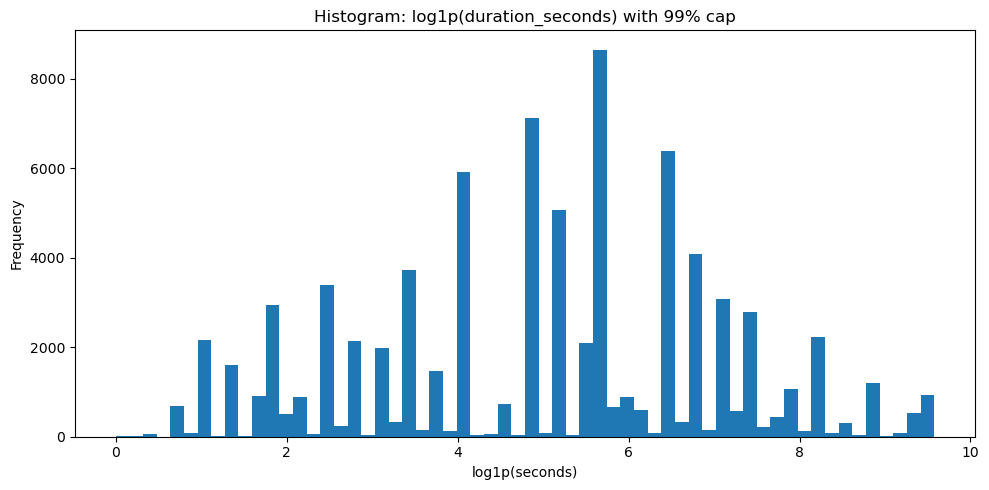

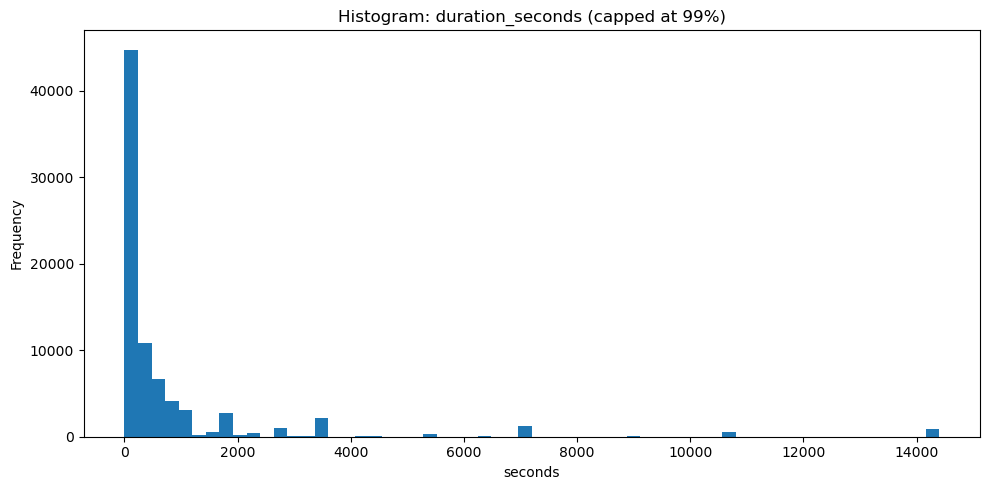

,datetime,city,state,country,shape,duration_seconds,duration_hm,comments_clean
559,1983-10-01 17:00:00,birmingham (uk/england),<NA>,gb,sphere,97836000.0,31 years,"Firstly, I was stunned and stared at the objec..."
53384,2010-06-03 23:30:00,ottawa (canada),on,ca,other,82800000.0,23000hrs,"((HOAX??)) I was out in a field near mil, base..."
74660,1991-09-15 18:00:00,greenbrier,ar,us,light,66276000.0,21 years,Orange or amber balls or orbs of light multipl...
64390,2012-08-10 21:00:00,finley,wa,us,light,52623200.0,2 months,There have been several flying objects in a pe...
38261,1983-04-03 00:00:00,dont know,<NA>,<NA>,<NA>,52623200.0,2 months,"Hi, I’m writing to you because I wanted to tal..."
69215,2002-08-24 01:00:00,englewood,fl,us,light,52623200.0,2 months,"bright stars, moving erratically, over the Gul..."
52709,1969-06-30 22:45:00,somerset (uk/england),<NA>,gb,cone,25248000.0,8 years,First time it was a bright light and missing t...
71172,2008-08-03 21:00:00,virginia beach,va,us,fireball,10526400.0,4 months,this object was very high up and emmited no so...
6991,2013-10-07 20:00:00,oklahoma,ok,<NA>,circle,10526400.0,4 months,Bright flying orb.
30596,1994-03-01 01:00:00,menifee,ca,us,unknown,10526400.0,4 months,Sun City / Menifee UFO sightings in 1994


In [12]:
# 1) Лог-распределение с каппингом хвоста
x = df["log_duration_cap"].dropna()

plt.figure(figsize=(10,5))
plt.hist(x, bins=60)
plt.title("Histogram: log1p(duration_seconds) with 99% cap")
plt.xlabel("log1p(seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) Посмотрим на реальные секунды на каппинге (для интерпретации)
x2 = df["duration_seconds_cap"].dropna()
plt.figure(figsize=(10,5))
plt.hist(x2, bins=60)
plt.title("Histogram: duration_seconds (capped at 99%)")
plt.xlabel("seconds")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3) Топ самых длинных кейсов (без каппинга)
display(
    df.sort_values("duration_seconds", ascending=False)[
        ["datetime","city","state","country","shape","duration_seconds","duration_hm","comments_clean"]
    ].head(10)
)


## 3.5 Комментарии: быстрые выводы (без тяжелого NLP)
- частотные слова
- “теги” по ключевым словам


,word,count
0,light,18096
1,lights,17966
2,sky,17081
3,object,15019
4,bright,13357
5,moving,9264
6,orange,8939
7,white,8173
8,red,7958
9,shaped,7059


C:\Users\Shaim\AppData\Local\Temp\ipykernel_24396\403662272.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tag_counts[tag] = text.str.contains(pat, regex=True, na=False).sum()


,tag,count
2,lights,32655
5,fast_speed,6804
4,sound_noise,3513
0,triangle,3352
1,disk_disc,1872
3,silent,1619
7,military,718
6,hover,359


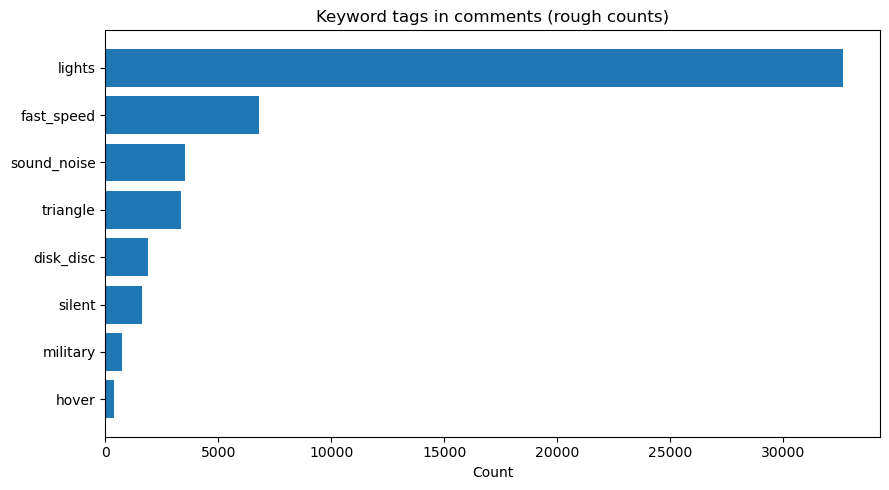

In [13]:
from collections import Counter

# простая токенизация
text = df["comments_clean"].dropna().astype(str).str.lower()
tokens = text.str.findall(r"[a-z']{3,}")  # английские слова длиной >=3
all_tokens = [w for lst in tokens for w in lst]

# минимальный стоп-лист (можешь расширить)
stop = set([
    "the","and","that","this","with","was","were","from","they","have","had","then","when",
    "there","their","what","into","out","over","just","like","very","could","would","about",
    "after","before","around","said","saw","see","too","been","because","while","where",
    "http","https","www"
])

freq = Counter(w for w in all_tokens if w not in stop)
top_words = pd.DataFrame(freq.most_common(30), columns=["word","count"])
display(top_words)

# теги по ключевым словам
patterns = {
    "triangle": r"\btriangle\b",
    "disk_disc": r"\b(disk|disc)\b",
    "lights": r"\blight(s)?\b",
    "silent": r"\bsilent\b",
    "sound_noise": r"\b(sound|noise|loud)\b",
    "fast_speed": r"\bfast|speed|rapid\b",
    "hover": r"\bhover\b",
    "military": r"\bmilitary|airforce|afb|base\b",
}

tag_counts = {}
for tag, pat in patterns.items():
    tag_counts[tag] = text.str.contains(pat, regex=True, na=False).sum()

tag_df = pd.DataFrame(tag_counts.items(), columns=["tag","count"]).sort_values("count", ascending=False)
display(tag_df)

plt.figure(figsize=(9,5))
plt.barh(tag_df["tag"][::-1], tag_df["count"][::-1])
plt.title("Keyword tags in comments (rough counts)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


# 4) Расширенный анализ: сезонность, гипотезы, задержки публикации, гео, статистика

Ниже:
4.1 Heatmap: hour × month (и day-of-week × hour)  
4.2 Проверка равномерности распределения (хи-квадрат)  
4.3 Lag posting: сколько дней проходит между событием и публикацией  
4.4 Гео: hexbin плотности по США  
4.5 Shape vs duration: сравнение распределений (Kruskal–Wallis)


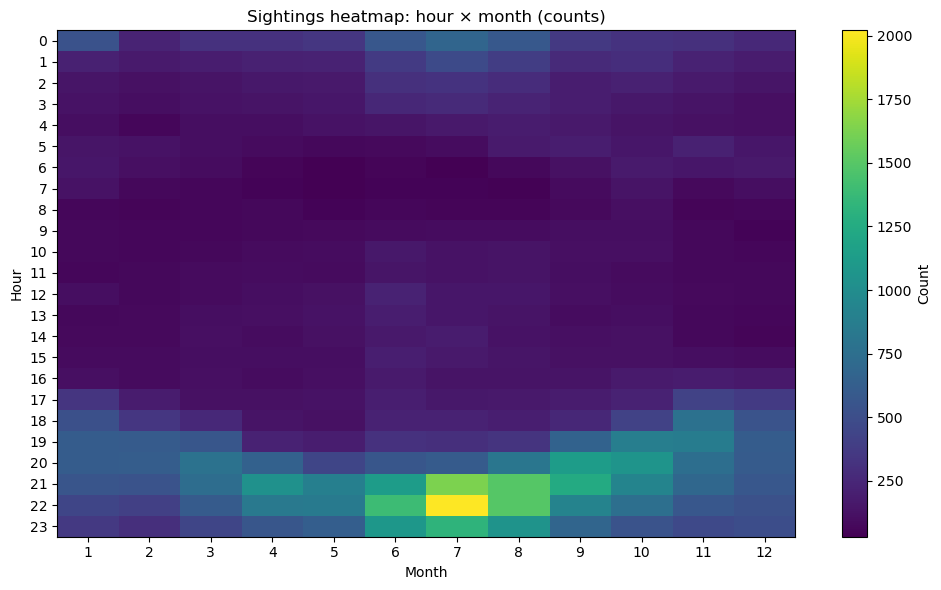

month,1,2,3,4,5,6,7,8,9,10,11,12
hour,,,,,,,,,,,,
0,530,225,314,316,346,570,681,580,359,319,305,257
1,212,174,191,215,219,369,478,395,265,289,223,180
2,143,121,132,160,165,305,323,286,190,215,174,143
3,129,107,129,134,150,255,268,230,191,162,135,114
4,102,67,106,100,131,141,166,181,165,133,122,115


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# берём только валидный dt
d = df[df["dt"].notna()].copy()

# hour x month heatmap (counts)
pivot = pd.pivot_table(d, index="hour", columns="month", values="datetime", aggfunc="count").fillna(0)

plt.figure(figsize=(10,6))
plt.imshow(pivot.values, aspect="auto")
plt.title("Sightings heatmap: hour × month (counts)")
plt.xlabel("Month")
plt.ylabel("Hour")
plt.xticks(np.arange(12), [str(m) for m in pivot.columns])
plt.yticks(np.arange(24), [str(h) for h in pivot.index])
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

display(pivot.astype(int).head())


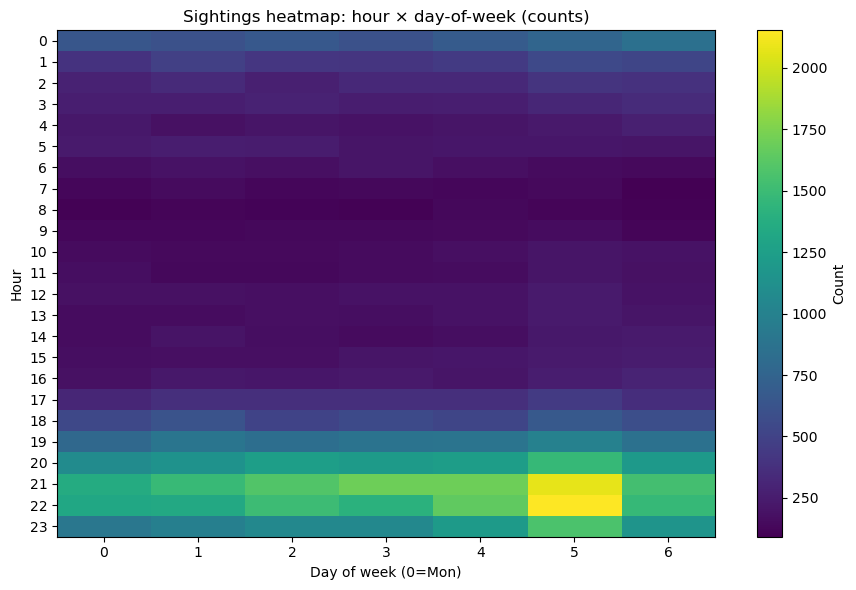

In [15]:
pivot2 = pd.pivot_table(d, index="hour", columns="dow", values="datetime", aggfunc="count").fillna(0)

plt.figure(figsize=(9,6))
plt.imshow(pivot2.values, aspect="auto")
plt.title("Sightings heatmap: hour × day-of-week (counts)")
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Hour")
plt.xticks(np.arange(7), [str(x) for x in pivot2.columns])
plt.yticks(np.arange(24), [str(h) for h in pivot2.index])
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()


## 4.2 Вероятность/статистика: хи-квадрат “равномерно ли по часам?”

Без SciPy сделаем вручную (чтобы не зависеть от пакетов).

In [16]:
import math

hour_counts = d["hour"].value_counts().sort_index()
obs = hour_counts.values
n = obs.sum()
exp = np.ones_like(obs) * (n / len(obs))

chi2 = ((obs - exp) ** 2 / exp).sum()
dfree = len(obs) - 1

# нормальная аппроксимация для p-value (грубая, но ок для ориентира):
# z = (chi2 - df) / sqrt(2*df)
z = (chi2 - dfree) / math.sqrt(2 * dfree)

print("Chi-square:", chi2)
print("df:", dfree)
print("z approx:", z)
print("Interpretation: если z >> 3, распределение точно не равномерное (очевидные пики).")


Chi-square: 72274.18393666286
df: 23
z approx: 10652.855894128852
Interpretation: если z >> 3, распределение точно не равномерное (очевидные пики).


## 4.3 Задержка публикации lag_days

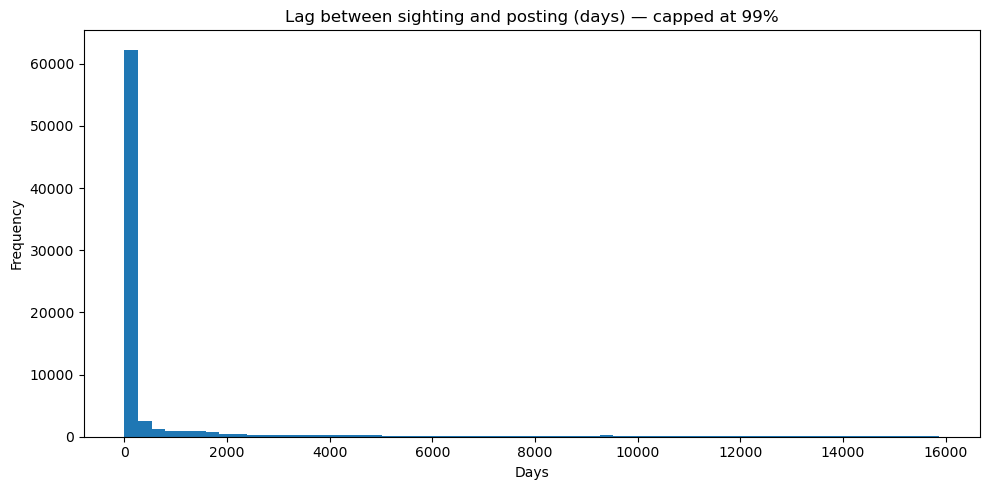

Lag days median: 25.54861111111111
Lag days mean: 995.433563443493
Lag days 90%: 2976.4947916666683
Lag days 99%: 13562.964375000001


In [17]:
lag = df["lag_days"].dropna()

# выкинем совсем отрицательные/странные (иногда dt/posted криво распарсены)
lag = lag[(lag >= 0) & (lag <= lag.quantile(0.99))]

plt.figure(figsize=(10,5))
plt.hist(lag, bins=60)
plt.title("Lag between sighting and posting (days) — capped at 99%")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Lag days median:", lag.median())
print("Lag days mean:", lag.mean())
print("Lag days 90%:", lag.quantile(0.90))
print("Lag days 99%:", lag.quantile(0.99))


## 4.4 Гео-плотность по США (hexbin)

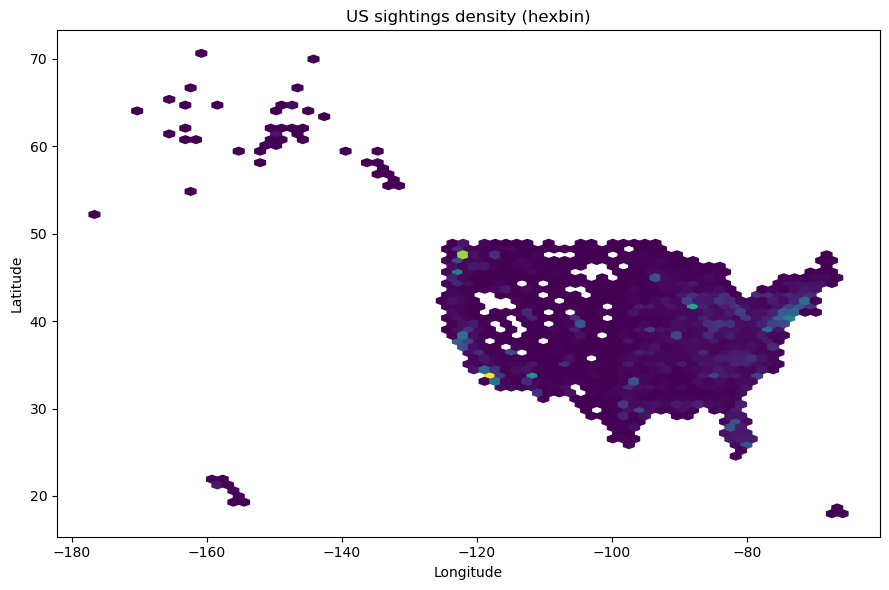

US geo rows: 65114


In [18]:
us_geo = df[(df["country"] == "us") & df["latitude"].notna() & df["longitude"].notna()].copy()

plt.figure(figsize=(9,6))
plt.hexbin(us_geo["longitude"], us_geo["latitude"], gridsize=70, mincnt=1)
plt.title("US sightings density (hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

print("US geo rows:", len(us_geo))


## 4.5 Shape vs duration: статистическое сравнение (без SciPy — через bootstrap)

Сравним медианы log_duration_cap между топ-формами: bootstrap CI.

In [19]:
def bootstrap_ci(x, stat=np.median, n_boot=2000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 30:
        return (np.nan, np.nan, np.nan)
    stats = []
    for _ in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        stats.append(stat(sample))
    stats = np.array(stats)
    lo = np.quantile(stats, alpha/2)
    hi = np.quantile(stats, 1-alpha/2)
    return (stat(x), lo, hi)

top_shapes = df["shape"].value_counts().head(8).index.tolist()
rows = []
for sh in top_shapes:
    x = df.loc[df["shape"] == sh, "log_duration_cap"].dropna().values
    med, lo, hi = bootstrap_ci(x, stat=np.median)
    rows.append((sh, len(x), med, lo, hi))

shape_ci = pd.DataFrame(rows, columns=["shape","n","median_log","ci_lo","ci_hi"]).sort_values("median_log", ascending=False)
display(shape_ci)


,shape,n,median_log,ci_lo,ci_hi
7,disk,5213,5.484797,5.198497,5.484797
0,light,16565,5.198497,5.198497,5.198497
1,triangle,7865,5.198497,5.198497,5.198497
2,circle,7608,5.198497,5.198497,5.198497
4,other,5649,5.198497,5.198497,5.198497
5,unknown,5584,5.198497,5.198497,5.484797
6,sphere,5387,5.198497,5.198497,5.198497
3,fireball,6208,4.795791,4.795791,4.795791


# 5) ML-блоки (легко и полезно)
5.1 Классификация: предсказываем shape (top-K, остальное other)  
5.2 Регрессия: предсказываем log_duration (простые модели)


## 5.1 Классификация: предсказываем shape (top-K, остальное other)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

K = 8
topk = df["shape"].value_counts().head(K).index

features = ["hour","month","year","state","country","comment_words"]  # начнём без geo и duration
dml = df[df["dt"].notna()].copy()

# target
dml["shape_k"] = np.where(dml["shape"].isin(topk), dml["shape"], "other")

# заполним пропуски и приведём типы
for c in ["state","country"]:
    if c in dml.columns:
        dml[c] = dml[c].astype("string").fillna("unknown")

for c in ["hour","month","year","comment_words"]:
    if c in dml.columns:
        dml[c] = pd.to_numeric(dml[c], errors="coerce")

dml = dml[features + ["shape_k"]].dropna(subset=["hour","month","year","comment_words","shape_k"])

X = dml[features]
y = dml["shape_k"].astype("string")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat = ["state","country"]
num = [c for c in features if c not in cat]

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
        ("num", "passthrough", num),
    ]
)

clf = Pipeline(steps=[
    ("pre", pre),
    ("model", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Classes:", sorted(y.unique()))
print(classification_report(y_test, pred))


C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classes: ['circle', 'disk', 'fireball', 'light', 'other', 'sphere', 'triangle', 'unknown']


C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      circle       0.00      0.00      0.00      1521
        disk       0.00      0.00      0.00      1043
    fireball       0.00      0.00      0.00      1242
       light       0.00      0.00      0.00      3313
       other       0.32      1.00      0.49      5178
      sphere       0.00      0.00      0.00      1077
    triangle       0.00      0.00      0.00      1573
     unknown       0.00      0.00      0.00      1117

    accuracy                           0.32     16064
   macro avg       0.04      0.12      0.06     16064
weighted avg       0.10      0.32      0.16     16064



C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion matrix (топ-классы)

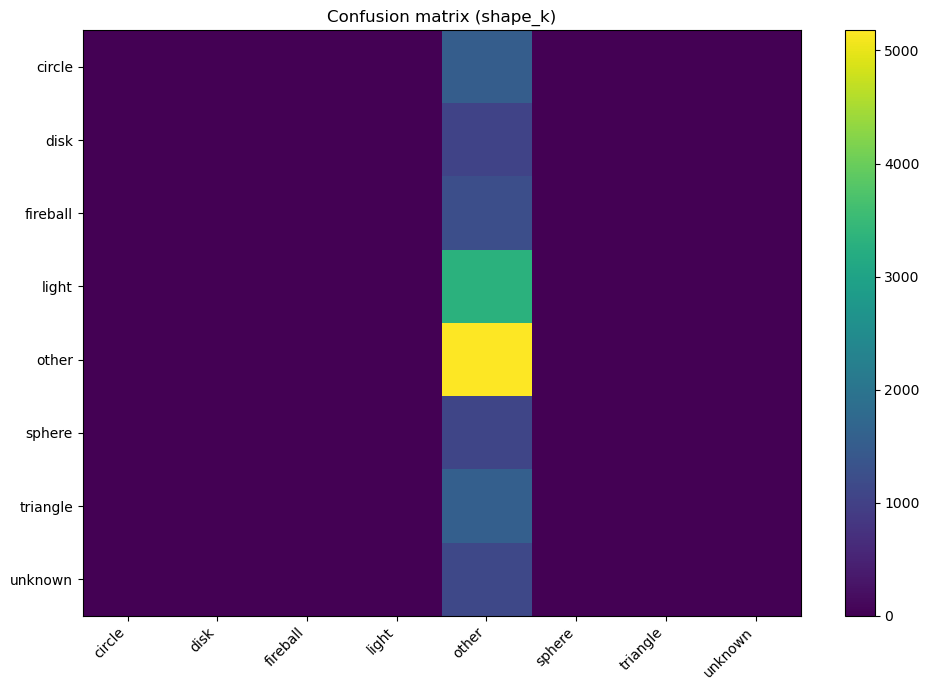

In [22]:
import matplotlib.pyplot as plt

labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(10,7))
plt.imshow(cm, aspect="auto")
plt.title("Confusion matrix (shape_k)")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()


Dataset size: (80316, 10)
Class distribution:
 shape_k
other       25891
light       16563
triangle     7864
circle       7607
fireball     6208
unknown      5584
sphere       5386
disk         5213
Name: count, dtype: Int64


C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification report:



C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      circle       0.00      0.00      0.00      1521
        disk       0.00      0.00      0.00      1043
    fireball       0.00      0.00      0.00      1242
       light       0.50      0.00      0.00      3313
       other       0.32      1.00      0.49      5178
      sphere       0.00      0.00      0.00      1077
    triangle       0.00      0.00      0.00      1573
     unknown       0.00      0.00      0.00      1117

    accuracy                           0.32     16064
   macro avg       0.10      0.13      0.06     16064
weighted avg       0.21      0.32      0.16     16064



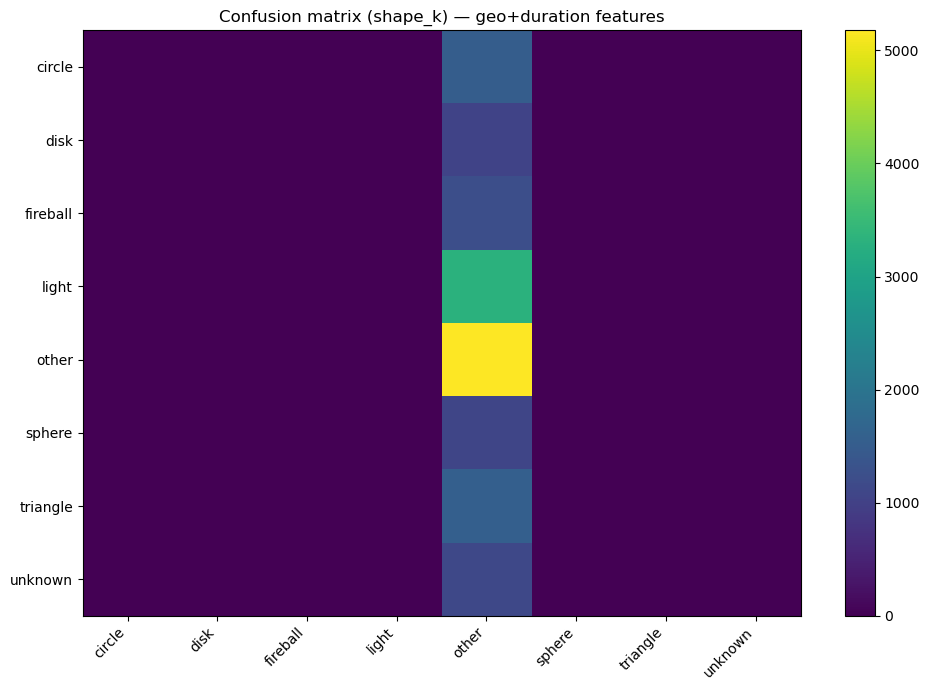

In [23]:
# 0) target: top-K shapes, rest -> "other"
K = 8
topk = df["shape"].value_counts().head(K).index

# 1) dataset for ML
features2 = ["hour","month","year","state","country","latitude","longitude","comment_words","log_duration_cap"]

dml2 = df[df["dt"].notna()].copy()
dml2["shape_k"] = np.where(dml2["shape"].isin(topk), dml2["shape"], "other")

# 2) fill categorical NA and enforce string dtype
dml2["state"] = dml2["state"].astype("string").fillna("unknown")
dml2["country"] = dml2["country"].astype("string").fillna("unknown")

# 3) numeric columns -> numeric (NaN if bad)
num_cols = ["hour","month","year","latitude","longitude","comment_words","log_duration_cap"]
for c in num_cols:
    dml2[c] = pd.to_numeric(dml2[c], errors="coerce")

# 4) keep only fully valid rows for these features
dml2 = dml2[features2 + ["shape_k"]].dropna()

X = dml2[features2]
y = dml2["shape_k"].astype("string")

print("Dataset size:", dml2.shape)
print("Class distribution:\n", y.value_counts().head(15))

# 5) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6) preprocessing
cat_cols = ["state", "country"]
num_cols = [c for c in features2 if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# 7) model
clf = Pipeline(steps=[
    ("pre", pre),
    ("model", LogisticRegression(max_iter=3000))
])

# 8) fit + evaluate
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("\nClassification report:\n")
print(classification_report(y_test, pred))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(10,7))
plt.imshow(cm, aspect="auto")
plt.title("Confusion matrix (shape_k) — geo+duration features")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 6) Topic Modeling по comments (TF-IDF + NMF)
Цели:
- извлечь 6–10 устойчивых тем из описаний
- посмотреть топ-слова тем
- распределение тем по годам и по формам (shape)


## 6.1 Очистка текста + подготовка корпуса

In [24]:
def clean_text_for_tfidf(s: str) -> str:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return ""
    s = str(s).lower()

    # убрать ссылки
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # заменить html-артефакты (если вдруг где-то остались)
    s = s.replace("&amp;", " ").replace("&#44;", ",").replace("&quot;", " ")

    # оставить только буквы/апострофы, остальное -> пробел
    s = re.sub(r"[^a-z'\s]", " ", s)

    # схлопнуть пробелы
    s = re.sub(r"\s+", " ", s).strip()
    return s

# корпус: берем очищенные комментарии (лучше comments_clean, если у тебя уже есть)
text_series = df["comments_clean"] if "comments_clean" in df.columns else df["comments"]
corpus = text_series.fillna("").map(clean_text_for_tfidf)

# фильтр: слишком короткие комментарии не несут темы
min_words = 8
mask = corpus.str.split().str.len() >= min_words

df_txt = df.loc[mask].copy()
df_txt["text_clean"] = corpus.loc[mask].values

print("Total rows:", len(df))
print("Rows for topic modeling:", len(df_txt))
df_txt[["datetime","shape","text_clean"]].head(3)

Total rows: 80332
Rows for topic modeling: 62020


,datetime,shape,text_clean
0,1949-10-10 20:30:00,cylinder,this event took place in early fall around it ...
1,1949-10-10 21:00:00,light,lackland afb tx lights racing across the sky m...
3,1956-10-10 21:00:00,circle,my older brother and twin sister were leaving ...


## 6.2 TF-IDF

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# небольшая кастомизация стоп-слов (плюс стандартные английские)
extra_stop = {
    "ufo","ufos","object","objects","sighting","saw","seen","looked","look",
    "sky","night","day","time","like","one","two","also","could","would",
    "really","got","get","going","back","around","still","right","left"
}

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),     # униграммы+биграммы смотрятся богаче
    min_df=10,             # выкидываем совсем редкие
    max_df=0.4,            # выкидываем слишком частые
    max_features=40000
)

X = vectorizer.fit_transform(df_txt["text_clean"])
print("TF-IDF matrix:", X.shape)


TF-IDF matrix: (62020, 9226)


## 6.3 NMF (6–10 тем) + топ-слова

In [26]:
from sklearn.decomposition import NMF

n_topics = 8  # попробуй 6, 8, 10 и сравни интерпретируемость
nmf = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=400
)

W = nmf.fit_transform(X)   # doc-topic weights
H = nmf.components_        # topic-term weights

feature_names = np.array(vectorizer.get_feature_names_out())

def top_words_for_topic(topic_idx, n=15):
    top_ids = np.argsort(H[topic_idx])[::-1][:n]
    return feature_names[top_ids]

topics = []
for t in range(n_topics):
    words = top_words_for_topic(t, n=15)
    topics.append((t, ", ".join(words)))

topics_df = pd.DataFrame(topics, columns=["topic_id", "top_words"])
display(topics_df)


,topic_id,top_words
0,0,"object, shaped, shaped object, cigar, cigar sh..."
1,1,"light, bright, white, bright light, white ligh..."
2,2,"note, nuforc, nuforc note, pd, possible, note ..."
3,3,"lights, red, red lights, white lights, white, ..."
4,4,"sky, night, night sky, saw, clear, orange, lig..."
5,5,"moving, orange, east, north, west, south, fast..."
6,6,"like, star, looked, looked like, star like, li..."
7,7,"craft, flying, ufo, seen, shaped craft, shaped..."


## 6.4 Назначим каждой записи “главную тему” + уверенность

In [27]:
df_txt["topic_id"] = W.argmax(axis=1)
df_txt["topic_weight"] = W.max(axis=1)

df_txt[["datetime","shape","topic_id","topic_weight","text_clean"]].head(5)


,datetime,shape,topic_id,topic_weight,text_clean
0,1949-10-10 20:30:00,cylinder,7,0.002442,this event took place in early fall around it ...
1,1949-10-10 21:00:00,light,3,0.021102,lackland afb tx lights racing across the sky m...
3,1956-10-10 21:00:00,circle,7,0.007406,my older brother and twin sister were leaving ...
4,1960-10-10 20:00:00,light,7,0.022903,as a marine st lt flying an fj b fighter attac...
5,1961-10-10 19:00:00,sphere,7,0.001561,my father is now my brother the girl with us n...


## 6.5 Визуализация: распределение тем (overall) + по годам
Overall распределение

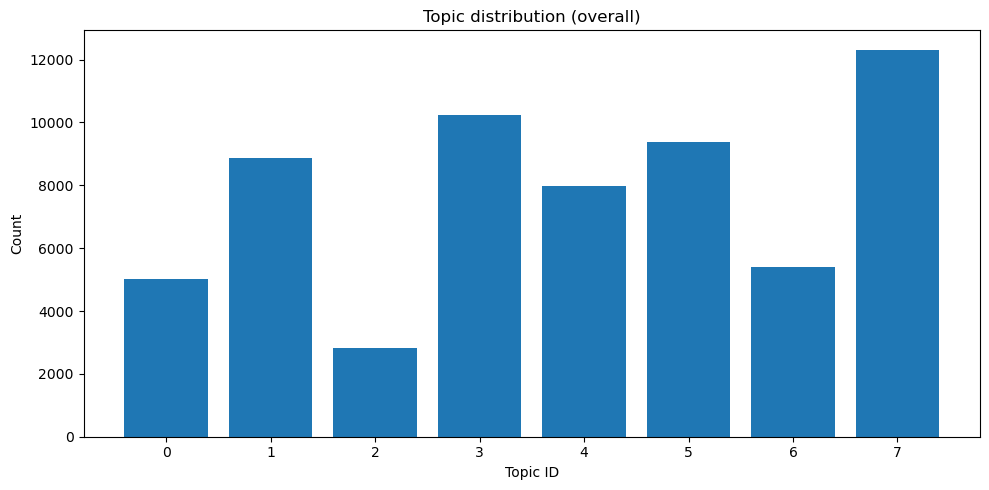

,count
topic_id,
0,5027
1,8855
2,2839
3,10240
4,7979
5,9364
6,5400
7,12316


In [28]:
import matplotlib.pyplot as plt

topic_counts = df_txt["topic_id"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("Topic distribution (overall)")
plt.xlabel("Topic ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(topic_counts.to_frame("count"))


## Темы по годам (stacked area по долям)

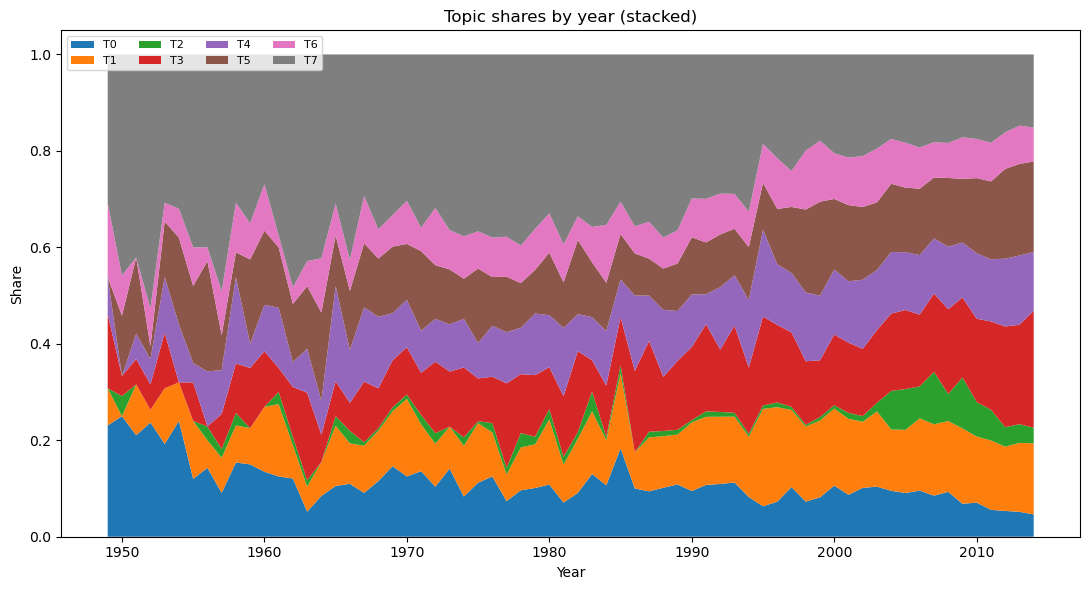

topic_id,0,1,2,3,4,5,6,7
year,,,,,,,,
2005,0.090650,0.130903,0.084628,0.163867,0.119810,0.134073,0.092868,0.183201
2006,0.095583,0.149891,0.066256,0.148805,0.123461,0.137581,0.085445,0.192976
2007,0.085217,0.147831,0.108735,0.162492,0.114233,0.126451,0.072999,0.182040
2008,0.093112,0.146747,0.056085,0.175878,0.129867,0.142118,0.072693,0.183501
2009,0.068307,0.156295,0.105644,0.165847,0.113748,0.132272,0.085962,0.171925
2010,0.070657,0.136995,0.071583,0.172786,0.135761,0.155816,0.081148,0.175255
2011,0.055760,0.143872,0.063651,0.183062,0.128880,0.161494,0.080221,0.183062
2012,0.053460,0.133285,0.040461,0.208715,0.140608,0.186196,0.075613,0.161662
2013,0.051622,0.142967,0.038764,0.206102,0.143543,0.189983,0.079447,0.147572


In [31]:
# year гарантированно как число
df_txt["year"] = pd.to_numeric(df_txt["dt"].dt.year, errors="coerce")

tmp = df_txt.dropna(subset=["year", "topic_id"]).copy()
tmp = tmp[tmp["year"].between(1949, 2014)]
tmp["year"] = tmp["year"].astype(int)

# 1) counts: год × тема
counts = tmp.pivot_table(index="year", columns="topic_id", aggfunc="size", fill_value=0).sort_index()

# 2) shares: доли тем в каждом году
share = counts.div(counts.sum(axis=1), axis=0).astype(float)

# 3) stackplot
x = share.index.to_numpy()
ys = [share[c].to_numpy() for c in share.columns]

plt.figure(figsize=(11,6))
plt.stackplot(x, *ys, labels=[f"T{c}" for c in share.columns])
plt.title("Topic shares by year (stacked)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

display(share.tail(10))


## 6.6 Темы по формам (shape): топ-10 форм × темы

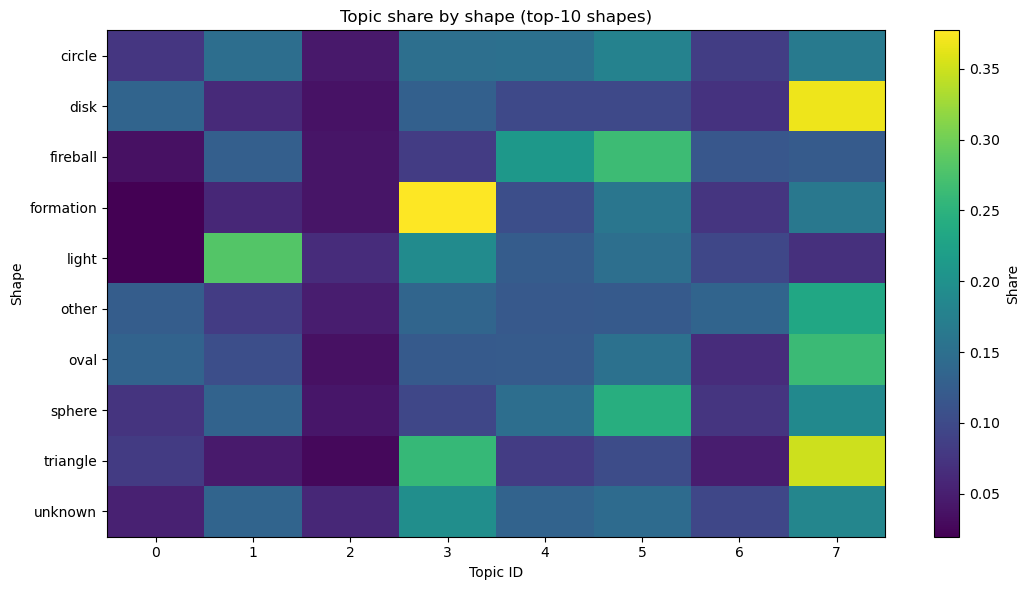

topic_id,0,1,2,3,4,5,6,7
shape,,,,,,,,
circle,0.075678,0.148660,0.043991,0.149840,0.151862,0.178662,0.084611,0.166695
disk,0.134648,0.061846,0.036766,0.129048,0.098369,0.098612,0.072559,0.368152
fireball,0.035580,0.127956,0.040221,0.082873,0.210166,0.264972,0.116464,0.121768
formation,0.019710,0.059647,0.040456,0.377075,0.105809,0.159751,0.074689,0.162863
light,0.020652,0.281928,0.065358,0.192752,0.124070,0.150419,0.096139,0.068682
other,0.124659,0.083560,0.048138,0.135786,0.118983,0.120799,0.134877,0.233197
oval,0.133883,0.105733,0.036045,0.121181,0.121867,0.152763,0.064538,0.263989
sphere,0.073602,0.133955,0.040726,0.095927,0.148430,0.243376,0.074828,0.189156
triangle,0.082280,0.045985,0.027919,0.259649,0.082772,0.102644,0.048776,0.349975


In [32]:
top_shapes = df["shape"].value_counts().head(10).index
tmp2 = df_txt[df_txt["shape"].isin(top_shapes)].copy()

shape_topic = pd.crosstab(tmp2["shape"], tmp2["topic_id"])
shape_topic_share = shape_topic.div(shape_topic.sum(axis=1), axis=0)

plt.figure(figsize=(11,6))
plt.imshow(shape_topic_share.values, aspect="auto")
plt.title("Topic share by shape (top-10 shapes)")
plt.xlabel("Topic ID")
plt.ylabel("Shape")
plt.xticks(range(shape_topic_share.shape[1]), [str(c) for c in shape_topic_share.columns])
plt.yticks(range(shape_topic_share.shape[0]), shape_topic_share.index)
plt.colorbar(label="Share")
plt.tight_layout()
plt.show()

display(shape_topic_share)


## 6.7 Быстрый sanity-check: примеры текстов по теме

In [36]:
def show_examples(topic_id, n=5):
    ex = df_txt[df_txt["topic_id"] == topic_id].sort_values("topic_weight", ascending=False).head(n)
    return ex[["datetime","city","state","country","shape","topic_weight","text_clean"]]

display(show_examples(0, n=5))


,datetime,city,state,country,shape,topic_weight,text_clean
65781,2010-08-13 22:45:00,pompey,ny,us,formation,0.118401,object seemed to be towing another object over...
43070,2010-05-18 22:00:00,helena,mt,us,disk,0.095473,disk shaped object military choppers all aroun...
45074,2008-05-30 17:00:00,madison,wi,us,other,0.091903,a black parallelogram shaped object was seen o...
61459,2011-07-03 22:10:00,oak lawn,il,us,circle,0.090410,red glare visible atom shaped object in shy
58547,2002-07-21 14:00:00,kitimat (canada),bc,ca,disk,0.088909,there is allot of detail on this saucer shaped...


## 6.8 Топ-тема по годам (dominant topic)

,year,dominant_topic,dominant_share
51,2000,7,0.204972
52,2001,7,0.213922
53,2002,7,0.210725
54,2003,7,0.195106
55,2004,7,0.175194
56,2005,7,0.183201
57,2006,7,0.192976
58,2007,7,0.182040
59,2008,7,0.183501
60,2009,7,0.171925


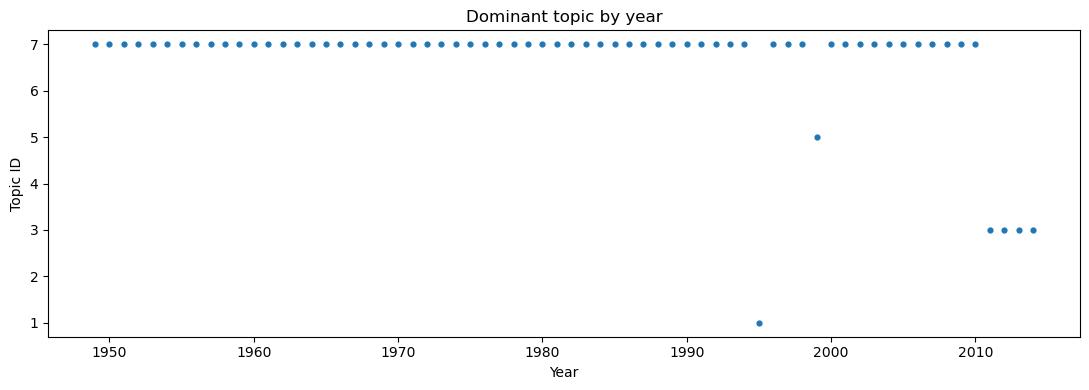

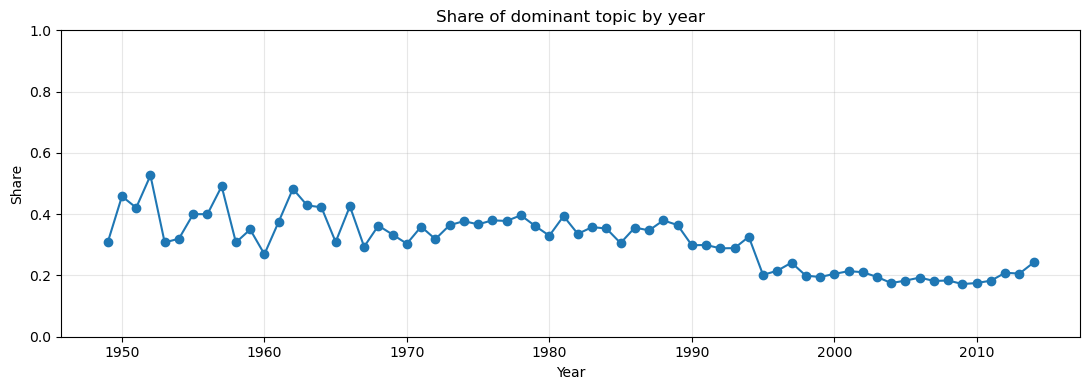

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# counts и share у тебя уже есть из предыдущей ячейки:
# counts: index=year, columns=topic_id
# share:  доли тем по годам

# 1) доминирующая тема в каждом году
dominant_topic = share.idxmax(axis=1)          # topic_id
dominant_share = share.max(axis=1)             # доля доминирующей темы

dom_df = pd.DataFrame({
    "dominant_topic": dominant_topic,
    "dominant_share": dominant_share
}).reset_index().rename(columns={"index": "year"})

display(dom_df.tail(15))

# 2) визуализация: (а) какая тема доминирует (точки), (б) насколько уверенно (линия доли)
plt.figure(figsize=(11,4))
plt.scatter(dom_df["year"], dom_df["dominant_topic"], s=12)
plt.title("Dominant topic by year")
plt.xlabel("Year")
plt.ylabel("Topic ID")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,4))
plt.plot(dom_df["year"], dom_df["dominant_share"], marker="o")
plt.title("Share of dominant topic by year")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6.9 Какие темы растут/падают (тренды)
Идея: берём долю темы по годам и оцениваем тренд простой линейной регрессией (slope).


,topic_id,slope_per_year,mean_share,delta_share
2,2,0.003135,0.034871,0.027732
5,5,0.002669,0.141921,0.069129
3,3,0.002083,0.164049,0.090674
4,4,0.000560,0.127216,0.013064
6,6,-0.000461,0.088382,-0.010214
1,1,-0.000511,0.149196,0.005144
0,0,-0.001673,0.084150,-0.048485
7,7,-0.005801,0.210215,-0.147045


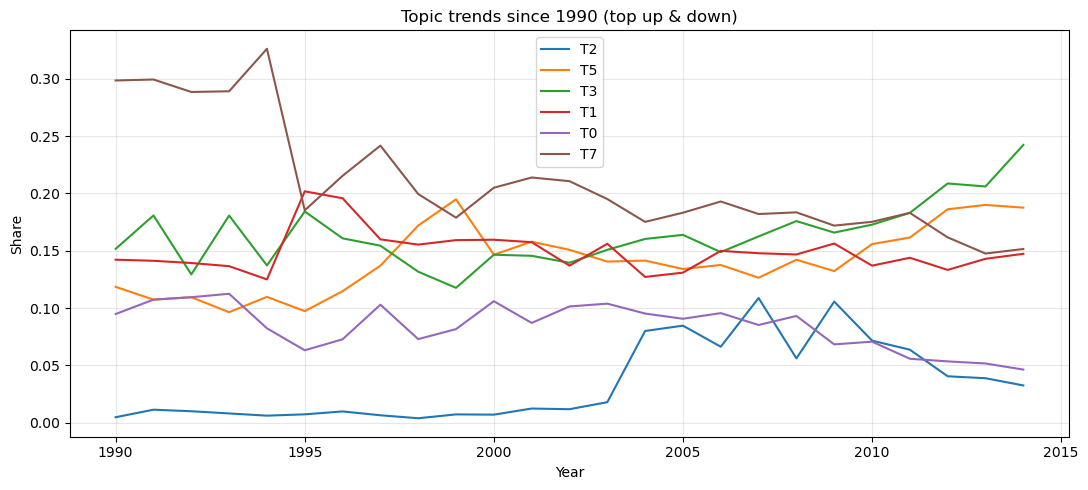

In [38]:
import numpy as np

# ограничимся диапазоном, где данных много (обычно после 1990/2000)
trend_start = 1990
share_tr = share[share.index >= trend_start].copy()

years = share_tr.index.to_numpy(dtype=float)

slopes = []
for t in share_tr.columns:
    y = share_tr[t].to_numpy(dtype=float)
    # slope из polyfit (линейный тренд)
    slope = np.polyfit(years, y, 1)[0]
    slopes.append((t, slope, y.mean(), y[-1] - y[0]))

trend_df = pd.DataFrame(slopes, columns=["topic_id", "slope_per_year", "mean_share", "delta_share"]).sort_values("slope_per_year", ascending=False)
display(trend_df)

top_up = trend_df.head(3)["topic_id"].tolist()
top_down = trend_df.tail(3)["topic_id"].tolist()

plt.figure(figsize=(11,5))
for t in top_up + top_down:
    plt.plot(share_tr.index, share_tr[t], label=f"T{t}")
plt.title(f"Topic trends since {trend_start} (top up & down)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6.10 NMF vs LDA (сравнение интерпретируемости)
Сделаем LDA на counts (CountVectorizer), вытащим топ-слова и сравним глазами.


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

n_topics_lda = 8  # для честного сравнения поставь как n_topics в NMF

count_vec = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=10,
    max_df=0.4,
    max_features=40000
)

Xc = count_vec.fit_transform(df_txt["text_clean"])
print("Count matrix:", Xc.shape)

lda = LatentDirichletAllocation(
    n_components=n_topics_lda,
    random_state=42,
    learning_method="batch",
    max_iter=20
)
lda_doc_topic = lda.fit_transform(Xc)
lda_topic_word = lda.components_

count_names = np.array(count_vec.get_feature_names_out())

def top_words_lda(topic_idx, n=15):
    ids = np.argsort(lda_topic_word[topic_idx])[::-1][:n]
    return count_names[ids]

lda_topics = []
for t in range(n_topics_lda):
    lda_topics.append((t, ", ".join(top_words_lda(t, 15))))

lda_topics_df = pd.DataFrame(lda_topics, columns=["topic_id", "top_words"])
display(lda_topics_df)


Count matrix: (62020, 9226)


,topic_id,top_words
0,0,"object, shaped, sky, shaped object, objects, s..."
1,1,"lights, flying, orange, red, sky, formation, m..."
2,2,"north, south, east, nuforc, note, pd, nuforc n..."
3,3,"saw, sky, green, driving, looked, noticed, hom..."
4,4,"night, ufo, saw, sky, seen, sighting, night sk..."
5,5,"light, bright, sky, moving, high, speed, fast,..."
6,6,"white, object, like, light, lights, bright, sh..."
7,7,"craft, orange, fireball, large, shaped craft, ..."


# 7) Теория вероятности / статистика


## 7.1 Равномерно ли распределены наблюдения по часам? (Monte Carlo p-value)
Идея: сравнить реальное распределение по часам с равномерным (1/24) через chi-square,
но p-value посчитаем симуляцией, без SciPy.


Observed chi2: 72274.18393666286
Monte Carlo p-value: 0.0


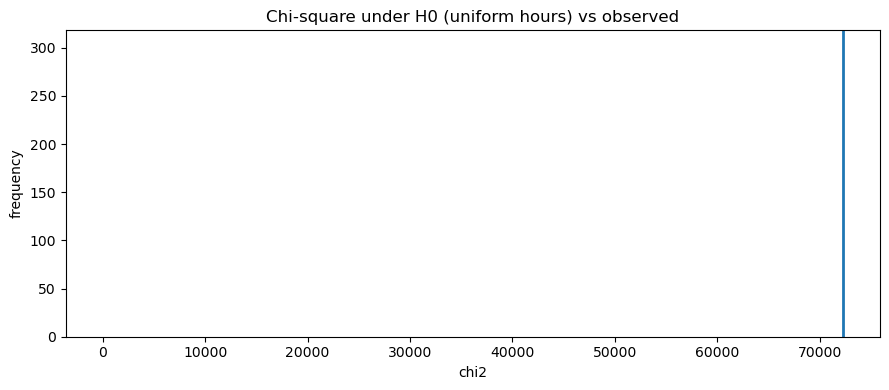

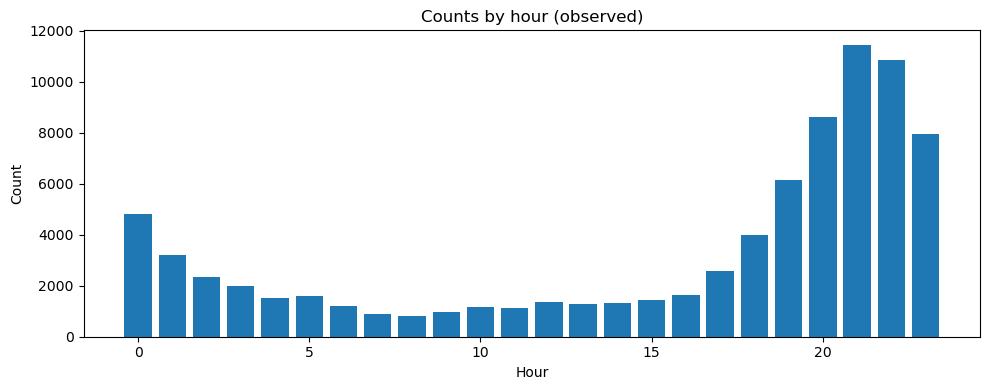

In [40]:
d = df[df["dt"].notna()].copy()
hours = d["hour"].dropna().astype(int)

obs = hours.value_counts().reindex(range(24), fill_value=0).to_numpy()
n = obs.sum()
exp = np.ones_like(obs) * (n / 24)

chi2_obs = ((obs - exp) ** 2 / exp).sum()
print("Observed chi2:", chi2_obs)

# Monte Carlo under H0: multinomial(n, p=1/24)
rng = np.random.default_rng(42)
B = 5000
sim = rng.multinomial(n, [1/24]*24, size=B)
chi2_sim = ((sim - exp) ** 2 / exp).sum(axis=1)

p_value = (chi2_sim >= chi2_obs).mean()
print("Monte Carlo p-value:", p_value)

plt.figure(figsize=(9,4))
plt.hist(chi2_sim, bins=50)
plt.axvline(chi2_obs, linewidth=2)
plt.title("Chi-square under H0 (uniform hours) vs observed")
plt.xlabel("chi2")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

# само распределение по часам
plt.figure(figsize=(10,4))
plt.bar(range(24), obs)
plt.title("Counts by hour (observed)")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 7.2 Пермутационный тест: выбранная форма чаще ночью?
Тестируем: P(night | shape=Х) выше, чем P(night | остальные).
Переставляем метки shape по строкам (hours фиксированы) → получаем p-value.


Shape of interest: triangle
n(shape_interest): 7865 n(other): 72467
Observed diff (night_share(shape) - night_share(other)): 0.07513168521075564
Permutation p-value (two-sided): 0.0
Permutation p-value (greater): 0.0


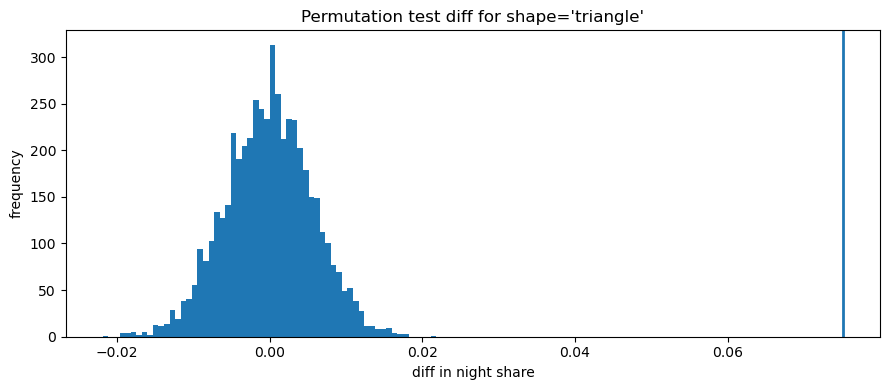

In [41]:
d = df[df["dt"].notna()].copy()

# night definition
is_night = d["hour"].isin([20,21,22,23,0,1,2,3,4]).to_numpy()

# выбираем форму: если triangle есть — берём её, иначе берём самую частую
shapes = d["shape"].fillna("unknown")
shape_interest = "triangle" if (shapes == "triangle").any() else shapes.value_counts().index[0]
print("Shape of interest:", shape_interest)

g = (shapes == shape_interest).to_numpy()
n1 = g.sum()
n0 = len(g) - n1
print("n(shape_interest):", n1, "n(other):", n0)

def night_share(mask):
    return is_night[mask].mean() if mask.sum() > 0 else np.nan

obs_diff = night_share(g) - night_share(~g)
print("Observed diff (night_share(shape) - night_share(other)):", obs_diff)

# permutation: shuffle g labels
rng = np.random.default_rng(42)
B = 5000
diffs = np.empty(B)

idx = np.arange(len(g))
for b in range(B):
    perm = rng.permutation(idx)
    g_perm = np.zeros_like(g, dtype=bool)
    g_perm[perm[:n1]] = True
    diffs[b] = night_share(g_perm) - night_share(~g_perm)

p_two_sided = (np.abs(diffs) >= abs(obs_diff)).mean()
p_greater = (diffs >= obs_diff).mean()

print("Permutation p-value (two-sided):", p_two_sided)
print("Permutation p-value (greater):", p_greater)

plt.figure(figsize=(9,4))
plt.hist(diffs, bins=60)
plt.axvline(obs_diff, linewidth=2)
plt.title(f"Permutation test diff for shape='{shape_interest}'")
plt.xlabel("diff in night share")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


## 7.3 Пуассон ли это? Счёт наблюдений по неделям + overdispersion
Сравним mean и variance недельных counts и проверим “насколько это похоже на Пуассон” симуляцией.


Weekly mean: 28.88601222581805
Weekly var: 1806.2542683005597
Index of dispersion (var/mean): 62.530412788725
Monte Carlo p-value for dispersion (Poisson): 0.0


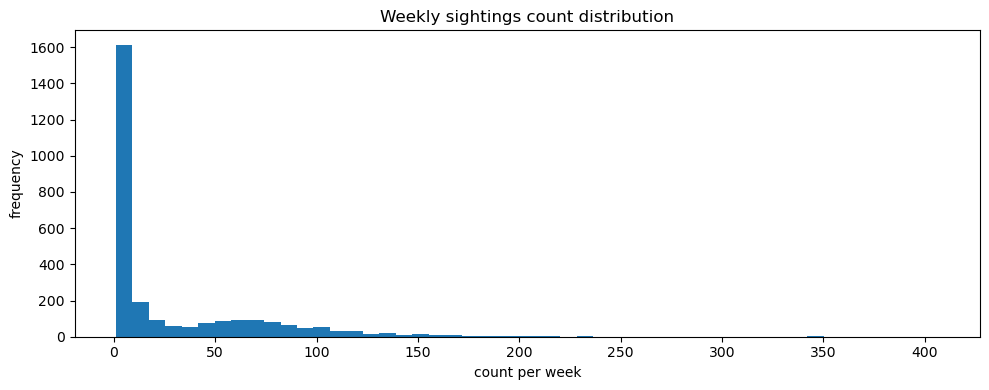

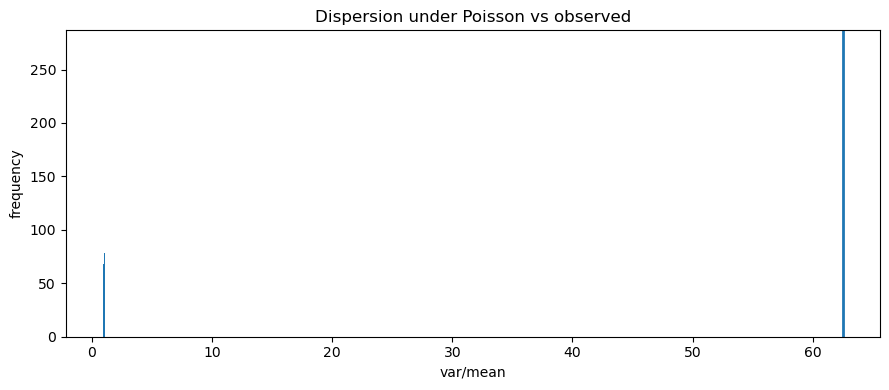

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = df[df["dt"].notna()].copy()
week = d["dt"].dt.to_period("W").dt.start_time
weekly = d.groupby(week).size().sort_index()

mu = weekly.mean()
var = weekly.var(ddof=1)
disp = var / mu if mu > 0 else np.nan

print("Weekly mean:", mu)
print("Weekly var:", var)
print("Index of dispersion (var/mean):", disp)

# сравним с Пуассоном: симулируем weekly counts ~ Poisson(mu)
rng = np.random.default_rng(42)
B = 5000
sim = rng.poisson(mu, size=(B, len(weekly)))
sim_mu = sim.mean(axis=1)
sim_var = sim.var(axis=1, ddof=1)
sim_disp = sim_var / sim_mu

p_disp = (sim_disp >= disp).mean()
print("Monte Carlo p-value for dispersion (Poisson):", p_disp)

plt.figure(figsize=(10,4))
plt.hist(weekly.values, bins=50)
plt.title("Weekly sightings count distribution")
plt.xlabel("count per week")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.hist(sim_disp, bins=60)
plt.axvline(disp, linewidth=2)
plt.title("Dispersion under Poisson vs observed")
plt.xlabel("var/mean")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


# 8) Геопространственный анализ



## 8.1 Hexbin плотности: до 2000 vs после 2000 (США)

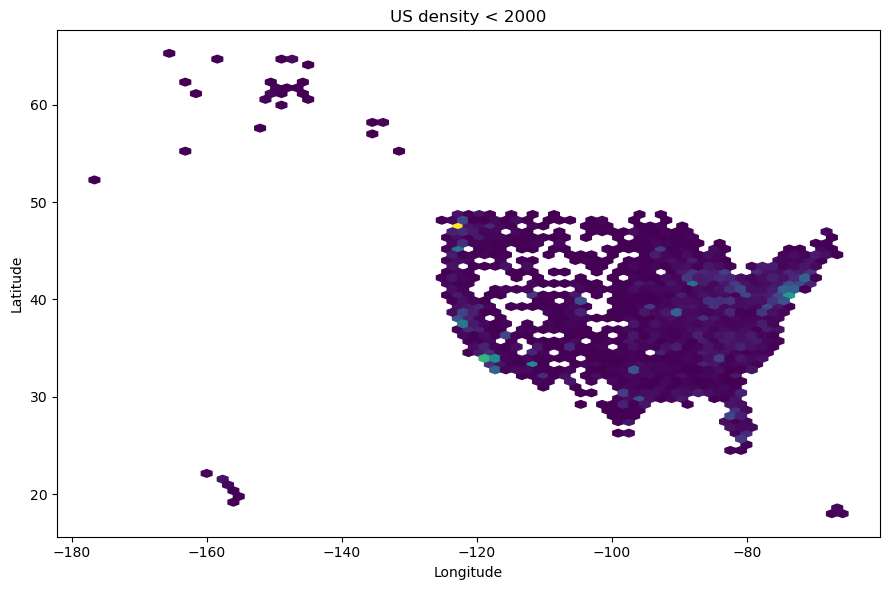

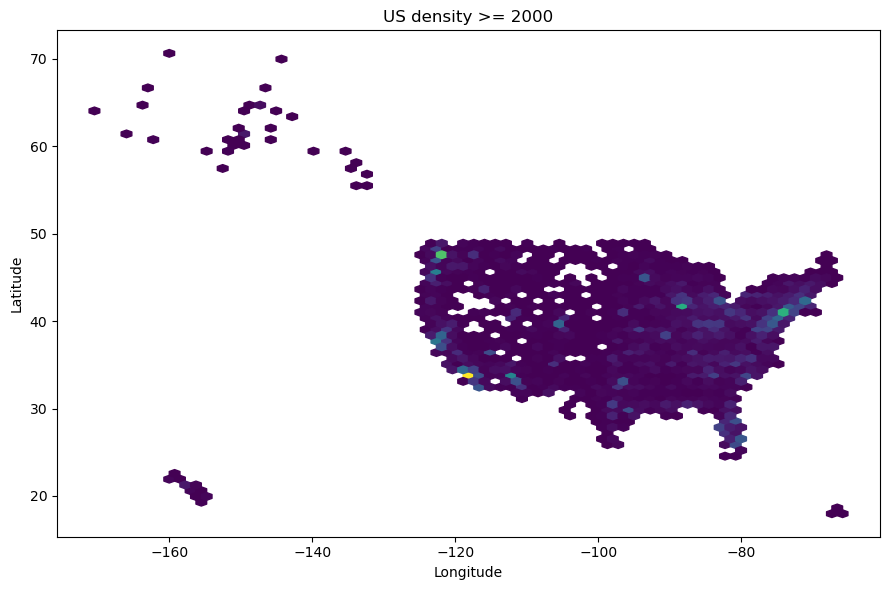

US rows <2000: 12301 >=2000: 52813


In [43]:
import matplotlib.pyplot as plt

us = df[(df["country"] == "us") & df["latitude"].notna() & df["longitude"].notna() & df["dt"].notna()].copy()
us["year"] = us["dt"].dt.year

us_pre = us[us["year"] < 2000]
us_post = us[us["year"] >= 2000]

for title, part in [("US density < 2000", us_pre), ("US density >= 2000", us_post)]:
    plt.figure(figsize=(9,6))
    plt.hexbin(part["longitude"], part["latitude"], gridsize=70, mincnt=1)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

print("US rows <2000:", len(us_pre), ">=2000:", len(us_post))


## 8.2 Гео-кластеры DBSCAN (haversine)
Находим пространственные кластеры сообщений в США и делаем краткую сводку по кластерам.


Clusters: 9 Noise points: 377


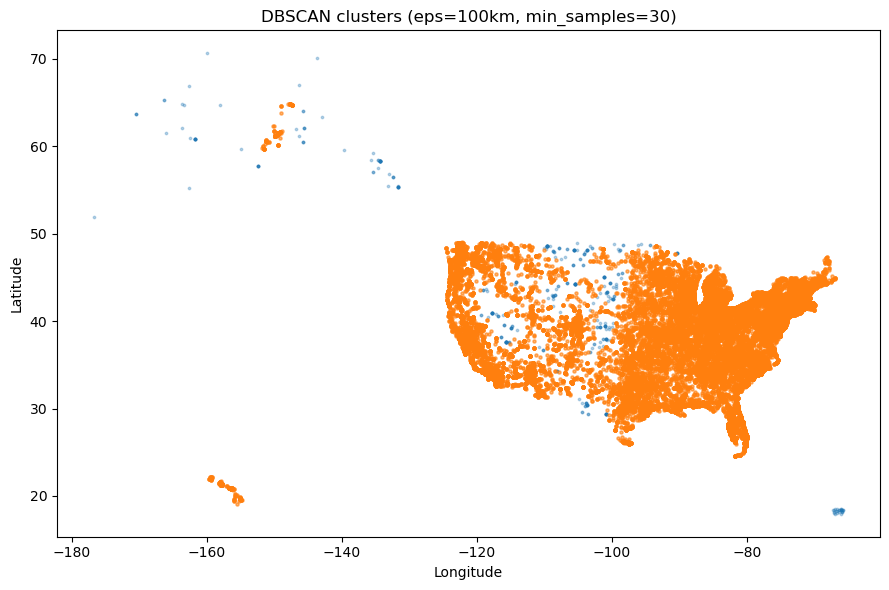

,n,lat_mean,lon_mean,top_shape,median_log_duration
cluster,,,,,
0,42512,37.827439,-83.863729,light,5.198497
2,21576,39.203545,-117.364243,light,5.198497
1,230,20.925350,-157.075967,light,5.484797
4,171,61.137586,-149.965396,light,5.707110
3,73,64.790658,-147.698661,light,5.707110
7,62,47.318356,-101.237352,light,5.707110
5,57,44.046009,-103.282110,light,4.795791
6,32,22.038559,-159.418394,light,5.707110
8,24,40.822662,-115.667234,light,6.803505


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

us = df[(df["country"] == "us") & df["latitude"].notna() & df["longitude"].notna() & df["dt"].notna()].copy()

# координаты в радианах для haversine
coords = np.radians(us[["latitude", "longitude"]].to_numpy())

# параметры:
# eps ~ 100 км => 100/6371 радиан
eps_km = 100
eps = eps_km / 6371.0
min_samples = 30

db = DBSCAN(eps=eps, min_samples=min_samples, metric="haversine")
labels = db.fit_predict(coords)
us["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters:", n_clusters, "Noise points:", (labels == -1).sum())

# scatter: шум серым, кластеры цветом (без явного задания цветов)
plt.figure(figsize=(9,6))
plt.scatter(us.loc[us["cluster"]==-1, "longitude"], us.loc[us["cluster"]==-1, "latitude"], s=3, alpha=0.3)
plt.scatter(us.loc[us["cluster"]!=-1, "longitude"], us.loc[us["cluster"]!=-1, "latitude"], s=5, alpha=0.6)
plt.title(f"DBSCAN clusters (eps={eps_km}km, min_samples={min_samples})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# summary table
cluster_summary = (
    us[us["cluster"] != -1]
    .groupby("cluster")
    .agg(
        n=("cluster","size"),
        lat_mean=("latitude","mean"),
        lon_mean=("longitude","mean"),
        top_shape=("shape", lambda s: s.value_counts().index[0] if s.notna().any() else "unknown"),
        median_log_duration=("log_duration_cap","median"),
    )
    .sort_values("n", ascending=False)
)

display(cluster_summary.head(15))


## 8.3 “Карта разнообразия форм”: grid-биннинг + энтропия
Группируем по 1°×1° ячейкам и считаем:
- count в ячейке
- энтропию форм (чем выше, тем разнообразнее формы в этой зоне)


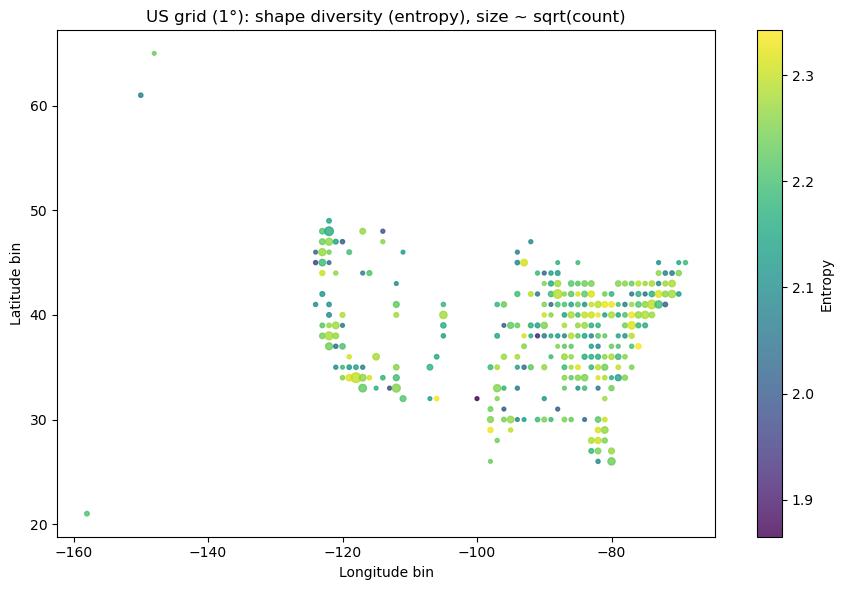

,lat_bin,lon_bin,shape_entropy,n
353,37,-76,2.342154,216
105,32,-106,2.333814,95
489,40,-82,2.332412,76
538,41,-80,2.330032,225
494,40,-77,2.329903,260
40,29,-98,2.329739,182
537,41,-81,2.326979,282
209,34,-82,2.319498,62
172,34,-119,2.317768,455
251,35,-85,2.317671,118


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

us = df[(df["country"] == "us") & df["latitude"].notna() & df["longitude"].notna()].copy()
us["lat_bin"] = us["latitude"].round(0).astype(int)   # 1 degree
us["lon_bin"] = us["longitude"].round(0).astype(int)

# оставим только более-менее частые формы, остальное -> other (чтобы энтропия не была “шумом”)
top_shapes = us["shape"].value_counts().head(12).index
us["shape_small"] = np.where(us["shape"].isin(top_shapes), us["shape"], "other")

def entropy(p):
    p = p[p > 0]
    return -(p * np.log(p)).sum()

cell = (
    us.groupby(["lat_bin","lon_bin"])["shape_small"]
      .value_counts(normalize=True)
      .rename("p")
      .reset_index()
)

cell_entropy = (
    cell.groupby(["lat_bin","lon_bin"])["p"]
        .apply(lambda s: entropy(s.to_numpy()))
        .rename("shape_entropy")
        .reset_index()
)

cell_count = us.groupby(["lat_bin","lon_bin"]).size().rename("n").reset_index()

grid = cell_entropy.merge(cell_count, on=["lat_bin","lon_bin"], how="left")
grid = grid[grid["n"] >= 50]  # фильтр, чтобы не рисовать ячейки с малым числом наблюдений

plt.figure(figsize=(9,6))
plt.scatter(grid["lon_bin"], grid["lat_bin"], s=np.sqrt(grid["n"]), c=grid["shape_entropy"], alpha=0.8)
plt.title("US grid (1°): shape diversity (entropy), size ~ sqrt(count)")
plt.xlabel("Longitude bin")
plt.ylabel("Latitude bin")
plt.colorbar(label="Entropy")
plt.tight_layout()
plt.show()

display(grid.sort_values("shape_entropy", ascending=False).head(15))
